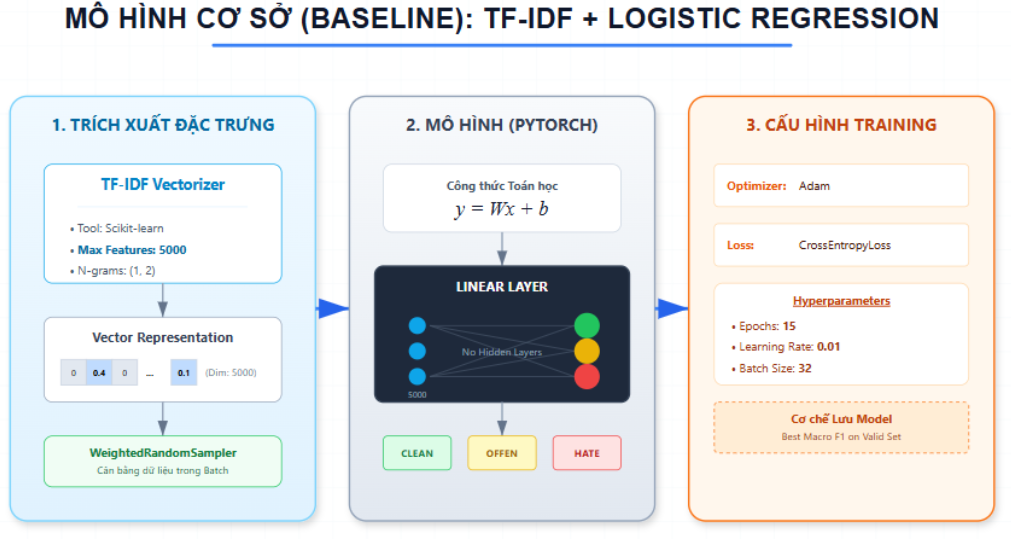

In [ ]:
"""
Baseline model: TF-IDF + Logistic Regression (thủ tục, đơn giản)
"""
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report
import os
import joblib


In [2]:
# --- 1. CẤU HÌNH ---
config = {
    "TRAIN_PATH": r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\data\processed\train.csv",
    "VALID_PATH": r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\data\processed\valid.csv",
    "MODEL_SAVE_PATH": r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\models_best\baseline_tfidf_torch.pth",
    "MAX_FEATURES": 5000,    # Chỉ lấy 5000 từ quan trọng nhất (TF-IDF)
    "BATCH_SIZE": 64,
    "EPOCHS": 15,            # LogReg hội tụ hơi lâu nên tăng epoch
    "LR": 0.01,
    "DEVICE": "cuda" if torch.cuda.is_available() else "cpu"
}

In [3]:
# --- 2. HÀM LOAD DATA ---
def load_data(path):
    df = pd.read_csv(path).dropna(subset=['free_text', 'label_id'])
    return df['free_text'].astype(str).tolist(), df['label_id'].astype(int).tolist()

# --- 3. DATASET CHO TF-IDF ---
# Vì TF-IDF ra vector thưa (Sparse), ta cần chuyển sang Dense Tensor cho PyTorch
class TfidfDataset(Dataset):
    def __init__(self, vectors, labels):
        self.vectors = vectors # Scipy sparse matrix
        self.labels = labels
    
    def __len__(self):
        return self.vectors.shape[0]
    
    def __getitem__(self, idx):
        # Chuyển dòng idx thành Dense Vector (Array thường)
        vector = self.vectors[idx].toarray()[0]
        return torch.tensor(vector, dtype=torch.float), torch.tensor(self.labels[idx], dtype=torch.long)


In [4]:
# --- 4. MÔ HÌNH LOGISTIC REGRESSION TỰ BUILD ---
# Phương trình: y = Wx + b (Không có hidden layer, không có activation ẩn)
class LogisticRegression_Torch(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression_Torch, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)
        
    def forward(self, x):
        # x shape: [batch_size, max_features] (Ví dụ: 32, 5000)
        outputs = self.linear(x)
        return outputs

In [5]:
# --- 5. HÀM TÍNH TRỌNG SỐ (SAMPLER) ---
def make_weights_for_balanced_classes(labels, nclasses):                        
    count = [0] * nclasses                                                      
    for item in labels: count[item] += 1                                                     
    weight_per_class = [0.] * nclasses                                      
    N = float(sum(count))                                                   
    for i in range(nclasses): weight_per_class[i] = N/float(count[i])                                 
    weight = [0] * len(labels)                                              
    for idx, val in enumerate(labels): weight[idx] = weight_per_class[val]                                  
    return weight

In [6]:
# --- 6. QUY TRÌNH TRAIN ---
def train():
    device = config["DEVICE"] 
    # 1. Load Text
    train_texts, train_labels = load_data(config["TRAIN_PATH"])
    val_texts, val_labels = load_data(config["VALID_PATH"])
    
    # 2. Tính TF-IDF (Feature Extraction)
    vectorizer = TfidfVectorizer(max_features=config["MAX_FEATURES"], ngram_range=(1,2))
    
    # Fit trên train, transform trên cả train và val
    X_train_tfidf = vectorizer.fit_transform(train_texts)
    X_val_tfidf = vectorizer.transform(val_texts)
    
    print(f"Shape train: {X_train_tfidf.shape}")
    
    # 3. Tạo Dataset & Loader
    train_ds = TfidfDataset(X_train_tfidf, train_labels)
    val_ds = TfidfDataset(X_val_tfidf, val_labels)
    
    # Sampler cân bằng dữ liệu
    weights = make_weights_for_balanced_classes(train_labels, 3)
    sampler = WeightedRandomSampler(torch.DoubleTensor(weights), len(weights))
    
    train_loader = DataLoader(train_ds, batch_size=config["BATCH_SIZE"], sampler=sampler, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=config["BATCH_SIZE"], shuffle=False)
    
    # 4. Init Model
    # Input dim chính là số lượng từ trong từ điển TF-IDF (5000)
    model = LogisticRegression_Torch(config["MAX_FEATURES"], 3)
    model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=config["LR"])
    criterion = nn.CrossEntropyLoss()

    # 5. Training Loop
    best_f1 = 0.0
    for epoch in range(config["EPOCHS"]):
        model.train()
        train_loss = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        # Validation
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                all_labels.extend(y.cpu().numpy())
        
        report = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)
        macro_f1 = report['macro avg']['f1-score']
        print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Macro F1: {macro_f1:.4f}")
        
        if macro_f1 > best_f1:
            best_f1 = macro_f1
            torch.save(model.state_dict(), config["MODEL_SAVE_PATH"])

    # KẾT QUẢ CUỐI CÙNG
    print("\n--- KẾT QUẢ BASELINE (TF-IDF + PYTORCH) ---")
    model.eval()
    final_preds, final_labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            final_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            final_labels.extend(y.cpu().numpy())
            
    print(classification_report(final_labels, final_preds, target_names=["CLEAN", "OFFENSIVE", "HATE"]))
    return model


In [7]:
if __name__ == "__main__":
    os.makedirs(os.path.dirname(config["MODEL_SAVE_PATH"]), exist_ok=True)
    model = train()


Shape train: (24046, 5000)
Epoch 1 | Loss: 0.8141 | Macro F1: 0.5479
Epoch 2 | Loss: 0.5822 | Macro F1: 0.5673
Epoch 3 | Loss: 0.4908 | Macro F1: 0.5711
Epoch 4 | Loss: 0.4315 | Macro F1: 0.5668
Epoch 5 | Loss: 0.3962 | Macro F1: 0.5637
Epoch 6 | Loss: 0.3654 | Macro F1: 0.5649
Epoch 7 | Loss: 0.3520 | Macro F1: 0.5670
Epoch 8 | Loss: 0.3263 | Macro F1: 0.5646
Epoch 9 | Loss: 0.3250 | Macro F1: 0.5645
Epoch 10 | Loss: 0.3045 | Macro F1: 0.5666
Epoch 11 | Loss: 0.3042 | Macro F1: 0.5637
Epoch 12 | Loss: 0.2852 | Macro F1: 0.5696
Epoch 13 | Loss: 0.2764 | Macro F1: 0.5602
Epoch 14 | Loss: 0.2752 | Macro F1: 0.5612
Epoch 15 | Loss: 0.2628 | Macro F1: 0.5528

--- KẾT QUẢ BASELINE (TF-IDF + PYTORCH) ---
              precision    recall  f1-score   support

       CLEAN       0.93      0.82      0.87      2190
   OFFENSIVE       0.24      0.40      0.30       212
        HATE       0.41      0.60      0.49       270

    accuracy                           0.76      2672
   macro avg       0

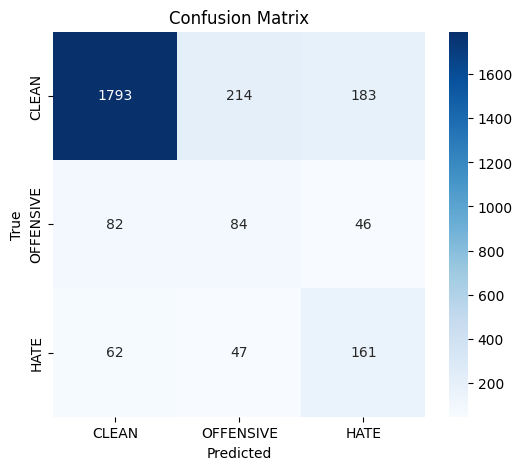

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

train_texts, _ = load_data(config["TRAIN_PATH"])
vectorizer = TfidfVectorizer(max_features=config["MAX_FEATURES"], ngram_range=(1,2))
vectorizer.fit(train_texts)

val_texts, val_labels = load_data(config["VALID_PATH"])
X_val_tfidf = vectorizer.transform(val_texts)
val_ds = TfidfDataset(X_val_tfidf, val_labels)
val_loader = DataLoader(val_ds, batch_size=config["BATCH_SIZE"], shuffle=False)

# predict
device = config["DEVICE"]
model.to(device)
model.eval()
all_preds = []
with torch.no_grad():
    for x, _ in val_loader:
        x = x.to(device)
        logits = model(x)
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

# plot confusion matrix
labels = ["CLEAN", "OFFENSIVE", "HATE"]
cm = confusion_matrix(val_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()